In [1]:
# ==========================================================
# Cell 1 — Imports and plotting defaults
# ==========================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# ==========================================================
# Cell 2 — File paths and experiment settings
# ==========================================================

from pathlib import Path


# ----------------------------------------------------------
# Working directory
# ----------------------------------------------------------

WORKING_DIR = Path(
    "/blue/juannanzhou/arindam.sarkar/"
    "BB-QTL_HT/7_HIPHOP_validation/Dose-dependent"
)

INPUT_DIR = WORKING_DIR / "inputs/1ml_plates"


# ----------------------------------------------------------
# Input files
# ----------------------------------------------------------

BY_FILE = INPUT_DIR / "BY.xlsx"
RM_FILE = INPUT_DIR / "RM.xlsx"

QTL_FILES = {
    "Chr7 QTL": INPUT_DIR / "CHR7_QTL.xlsx",
    "Chr8 QTL": INPUT_DIR / "CHR8_QTL.xlsx",
    "Chr13 QTL": INPUT_DIR / "CHR13_QTL.xlsx",
    "Chr15 QTL": INPUT_DIR / "CHR15_QTL.xlsx",
}


# ----------------------------------------------------------
# Concentration order
# ----------------------------------------------------------

CONCENTRATION_ORDER = [
    "0x",
    "0.25x",
    "0.50x",
    "1.0x",
]

CONCENTRATION_TITLES = {
    "0x": "0× MIC",
    "0.25x": "0.25× MIC",
    "0.50x": "0.5× MIC",
    "1.0x": "1× MIC",
}


# ----------------------------------------------------------
# Output folders
# ----------------------------------------------------------

OD_OUTDIR = WORKING_DIR / "OD600_1x4_figures"
FD_OUTDIR = WORKING_DIR / "FD_1x4_figures"
SUMMARY_OUTDIR = WORKING_DIR / "summary_tables"

for folder in [
    OD_OUTDIR,
    FD_OUTDIR,
    SUMMARY_OUTDIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ----------------------------------------------------------
# Confirm that directories exist
# ----------------------------------------------------------

if not WORKING_DIR.exists():
    raise FileNotFoundError(
        f"Working directory not found:\n{WORKING_DIR}"
    )

if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Input directory not found:\n{INPUT_DIR}"
    )


# ----------------------------------------------------------
# Confirm that all required input files exist
# ----------------------------------------------------------

required_files = [
    BY_FILE,
    RM_FILE,
    *QTL_FILES.values()
]

missing_files = [
    str(file_path)
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following input files were not found:\n\n"
        + "\n".join(missing_files)
        + "\n\nCheck the filenames inside:\n"
        + str(INPUT_DIR)
    )


print("Working directory:")
print(WORKING_DIR)

print("\nInput directory:")
print(INPUT_DIR)

print("\nAll input files found:")

for file_path in required_files:
    print("  ", file_path.name)

print("\nOutput directories:")

print("  OD600 figures:", OD_OUTDIR)
print("  FD figures:", FD_OUTDIR)
print("  Summary tables:", SUMMARY_OUTDIR)

Working directory:
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent

Input directory:
/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/inputs/1ml_plates

All input files found:
   BY.xlsx
   RM.xlsx
   CHR7_QTL.xlsx
   CHR8_QTL.xlsx
   CHR13_QTL.xlsx
   CHR15_QTL.xlsx

Output directories:
  OD600 figures: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/OD600_1x4_figures
  FD figures: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/FD_1x4_figures
  Summary tables: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables


In [3]:
# ==========================================================
# Cell 3 — Functions to read and reshape the Excel files
# ==========================================================

# Expected column format:
# ERG4 Rep1
# ERG4 Rep2
# ERG4 Rep3
#
# BY Rep1
# BY Rep2
# BY Rep3

COLUMN_PATTERN = re.compile(
    r"^(.*?)\s+Rep(\d+)$",
    flags=re.IGNORECASE
)


def read_excel_wide(file_path: Path) -> pd.DataFrame:
    """
    Read one Excel workbook and standardize the first column
    as 'Concentration'.
    """

    df = pd.read_excel(file_path)

    if df.empty:
        raise ValueError(
            f"{file_path.name} is empty."
        )

    # Rename first column to Concentration
    df = df.rename(
        columns={
            df.columns[0]: "Concentration"
        }
    )

    df["Concentration"] = (
        df["Concentration"]
        .astype(str)
        .str.strip()
    )

    observed_concentrations = set(
        df["Concentration"]
    )

    expected_concentrations = set(
        CONCENTRATION_ORDER
    )

    unexpected = sorted(
        observed_concentrations
        - expected_concentrations
    )

    if unexpected:
        raise ValueError(
            f"{file_path.name} contains unexpected "
            f"concentration labels: {unexpected}\n"
            f"Expected: {CONCENTRATION_ORDER}"
        )

    missing = [
        concentration
        for concentration in CONCENTRATION_ORDER
        if concentration not in observed_concentrations
    ]

    if missing:
        raise ValueError(
            f"{file_path.name} is missing "
            f"concentrations: {missing}"
        )

    return df


def wide_to_long(
    df: pd.DataFrame,
    source_file: str
) -> pd.DataFrame:
    """
    Convert a wide workbook such as:

        Concentration | ERG4 Rep1 | ERG4 Rep2 | ERG4 Rep3

    into long format:

        Concentration | Strain | Replicate | OD600
    """

    long_parts = []

    for column in df.columns:

        if column == "Concentration":
            continue

        column_name = str(column).strip()

        match = COLUMN_PATTERN.match(
            column_name
        )

        if match is None:
            raise ValueError(
                f"Could not interpret column "
                f"'{column}' in {source_file}.\n"
                "Expected format: '<strain> Rep<number>', "
                "for example 'ERG4 Rep1'."
            )

        strain = match.group(1).strip()
        replicate = int(match.group(2))

        part = df[
            ["Concentration", column]
        ].copy()

        part = part.rename(
            columns={
                column: "OD600"
            }
        )

        part["Strain"] = strain
        part["Replicate"] = replicate
        part["Source_file"] = source_file

        long_parts.append(part)

    long_df = pd.concat(
        long_parts,
        ignore_index=True
    )

    long_df["OD600"] = pd.to_numeric(
        long_df["OD600"],
        errors="coerce"
    )

    if long_df["OD600"].isna().any():

        bad_rows = long_df.loc[
            long_df["OD600"].isna()
        ]

        raise ValueError(
            f"Missing or nonnumeric OD600 values "
            f"were found in {source_file}:\n\n"
            + bad_rows.to_string(index=False)
        )

    expected_replicates = {1, 2, 3}

    observed_replicates = set(
        long_df["Replicate"].unique()
    )

    if observed_replicates != expected_replicates:
        raise ValueError(
            f"{source_file} contains replicates "
            f"{sorted(observed_replicates)}.\n"
            "Expected exactly Rep1, Rep2, and Rep3."
        )

    return long_df

In [7]:
# ==========================================================
# Cell 4 — Load BY and RM and append them to every QTL dataset
# ==========================================================

# ----------------------------------------------------------
# Load BY control
# ----------------------------------------------------------

by_wide = read_excel_wide(
    BY_FILE
)

by_long = wide_to_long(
    by_wide,
    BY_FILE.name
)

by_strains = set(
    by_long["Strain"].unique()
)

if by_strains != {"BY"}:
    raise ValueError(
        f"{BY_FILE.name} should contain only BY, "
        f"but the following strain names were found: "
        f"{sorted(by_strains)}"
    )


# ----------------------------------------------------------
# Load RM control
# ----------------------------------------------------------

rm_wide = read_excel_wide(
    RM_FILE
)

rm_long = wide_to_long(
    rm_wide,
    RM_FILE.name
)

rm_strains = set(
    rm_long["Strain"].unique()
)

if rm_strains != {"RM"}:
    raise ValueError(
        f"{RM_FILE.name} should contain only RM, "
        f"but the following strain names were found: "
        f"{sorted(rm_strains)}"
    )


# ----------------------------------------------------------
# Load each QTL workbook and append BY and RM
# ----------------------------------------------------------

qtl_data = {}

for qtl_name, qtl_file in QTL_FILES.items():

    qtl_wide = read_excel_wide(
        qtl_file
    )

    qtl_long = wide_to_long(
        qtl_wide,
        qtl_file.name
    )

    duplicate_controls = sorted(
        set(qtl_long["Strain"])
        & {"BY", "RM"}
    )

    if duplicate_controls:
        raise ValueError(
            f"{qtl_file.name} already contains the following "
            f"control strain(s): {duplicate_controls}.\n"
            "Remove them from the QTL workbook because BY and RM "
            "are appended from their separate workbooks."
        )

    # Explicitly append BY and RM to all KO strains
    combined = pd.concat(
        [
            qtl_long,
            by_long.copy(),
            rm_long.copy()
        ],
        ignore_index=True
    )

    # Set concentration order
    combined["Concentration"] = pd.Categorical(
        combined["Concentration"],
        categories=CONCENTRATION_ORDER,
        ordered=True
    )

    combined = combined.sort_values(
        [
            "Concentration",
            "Strain",
            "Replicate"
        ]
    ).reset_index(drop=True)

    qtl_data[qtl_name] = combined


# ----------------------------------------------------------
# Display strains included in each QTL dataset
# ----------------------------------------------------------

for qtl_name, df in qtl_data.items():

    ko_strains = [
        strain
        for strain in df["Strain"].drop_duplicates()
        if strain not in {"BY", "RM"}
    ]

    strain_order = ko_strains + ["BY", "RM"]

    print(f"\n{qtl_name}")
    print("Strains:", ", ".join(strain_order))
    print("BY appended:", "BY" in strain_order)
    print("RM appended:", "RM" in strain_order)


Chr7 QTL
Strains: ERG4, PDR1, BY, RM
BY appended: True
RM appended: True

Chr8 QTL
Strains: ERG11, STP2, YHR007C-A, BY, RM
BY appended: True
RM appended: True

Chr13 QTL
Strains: ADH6, FET4, YMR317W, YMR320W, BY, RM
BY appended: True
RM appended: True

Chr15 QTL
Strains: DUF1, ELG1, HAL9, MDM32, MPD2, MSH2, PNO1, SPP2, BY, RM
BY appended: True
RM appended: True


In [8]:
# ==========================================================
# Cell 5 — Calculate replicate-wise Fitness Defect
# ==========================================================

def calculate_fitness_defect(
    long_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Calculate Fitness Defect separately for each strain
    and replicate:

        FD = log2(
            OD600_treatment
            /
            OD600_control_0x
        )

    For example:

        ERG4 Rep1 at 0.5x
        divided by
        ERG4 Rep1 at 0x

    This means each strain is normalized to its own
    untreated growth in the matching replicate.
    """

    df = long_df.copy()


    # ------------------------------------------------------
    # Extract untreated 0x OD600 for each strain-replicate
    # ------------------------------------------------------

    baseline = (
        df.loc[
            df["Concentration"] == "0x",
            [
                "Strain",
                "Replicate",
                "OD600"
            ]
        ]
        .rename(
            columns={
                "OD600": "OD600_0x"
            }
        )
    )


    # Each strain-replicate should have only one 0x value
    duplicated_baselines = baseline.duplicated(
        subset=[
            "Strain",
            "Replicate"
        ],
        keep=False
    )

    if duplicated_baselines.any():

        duplicate_rows = baseline.loc[
            duplicated_baselines
        ]

        raise ValueError(
            "More than one 0x baseline was found "
            "for at least one strain-replicate:\n\n"
            + duplicate_rows.to_string(index=False)
        )


    # ------------------------------------------------------
    # Merge untreated baseline onto all concentrations
    # ------------------------------------------------------

    df = df.merge(
        baseline,
        on=[
            "Strain",
            "Replicate"
        ],
        how="left",
        validate="many_to_one"
    )


    # ------------------------------------------------------
    # Validate baseline values
    # ------------------------------------------------------

    if df["OD600_0x"].isna().any():

        missing_baselines = (
            df.loc[
                df["OD600_0x"].isna(),
                [
                    "Strain",
                    "Replicate"
                ]
            ]
            .drop_duplicates()
        )

        raise ValueError(
            "A 0x baseline is missing for:\n\n"
            + missing_baselines.to_string(index=False)
        )


    if (df["OD600"] <= 0).any():

        invalid_rows = df.loc[
            df["OD600"] <= 0,
            [
                "Strain",
                "Concentration",
                "Replicate",
                "OD600"
            ]
        ]

        raise ValueError(
            "OD600 must be greater than zero "
            "before calculating log2 Fitness Defect:\n\n"
            + invalid_rows.to_string(index=False)
        )


    if (df["OD600_0x"] <= 0).any():

        invalid_baselines = (
            df.loc[
                df["OD600_0x"] <= 0,
                [
                    "Strain",
                    "Replicate",
                    "OD600_0x"
                ]
            ]
            .drop_duplicates()
        )

        raise ValueError(
            "Untreated OD600 values must be greater than zero:\n\n"
            + invalid_baselines.to_string(index=False)
        )


    # ------------------------------------------------------
    # Calculate Fitness Defect
    # ------------------------------------------------------

    df["FD"] = np.log2(
        df["OD600"]
        /
        df["OD600_0x"]
    )


    return df


# Calculate FD for every QTL dataset
qtl_data_with_fd = {
    qtl_name: calculate_fitness_defect(df)
    for qtl_name, df in qtl_data.items()
}


# At 0x MIC, FD should equal zero for every strain
for qtl_name, df in qtl_data_with_fd.items():

    untreated_fd = df.loc[
        df["Concentration"] == "0x",
        "FD"
    ]

    if not np.allclose(
        untreated_fd,
        0.0
    ):
        raise ValueError(
            f"0x FD values are not zero for {qtl_name}."
        )

print(
    "Fitness Defect calculated successfully "
    "for all QTLs, including BY & RM."
)

Fitness Defect calculated successfully for all QTLs, including BY & RM.


In [10]:
# ==========================================================
# Cell 5 — Calculate replicate-wise Fitness Defect
# ==========================================================

def calculate_fitness_defect(
    long_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Calculate Fitness Defect separately for each strain
    and replicate:

        FD = log2(
            OD600_treatment
            /
            OD600_control_0x
        )

    For example:

        ERG4 Rep1 at 0.5x
        divided by
        ERG4 Rep1 at 0x

    This means each strain is normalized to its own
    untreated growth in the matching replicate.
    """

    df = long_df.copy()


    # ------------------------------------------------------
    # Extract untreated 0x OD600 for each strain-replicate
    # ------------------------------------------------------

    baseline = (
        df.loc[
            df["Concentration"] == "0x",
            [
                "Strain",
                "Replicate",
                "OD600"
            ]
        ]
        .rename(
            columns={
                "OD600": "OD600_0x"
            }
        )
    )


    # Each strain-replicate should have only one 0x value
    duplicated_baselines = baseline.duplicated(
        subset=[
            "Strain",
            "Replicate"
        ],
        keep=False
    )

    if duplicated_baselines.any():

        duplicate_rows = baseline.loc[
            duplicated_baselines
        ]

        raise ValueError(
            "More than one 0x baseline was found "
            "for at least one strain-replicate:\n\n"
            + duplicate_rows.to_string(index=False)
        )


    # ------------------------------------------------------
    # Merge untreated baseline onto all concentrations
    # ------------------------------------------------------

    df = df.merge(
        baseline,
        on=[
            "Strain",
            "Replicate"
        ],
        how="left",
        validate="many_to_one"
    )


    # ------------------------------------------------------
    # Validate baseline values
    # ------------------------------------------------------

    if df["OD600_0x"].isna().any():

        missing_baselines = (
            df.loc[
                df["OD600_0x"].isna(),
                [
                    "Strain",
                    "Replicate"
                ]
            ]
            .drop_duplicates()
        )

        raise ValueError(
            "A 0x baseline is missing for:\n\n"
            + missing_baselines.to_string(index=False)
        )


    if (df["OD600"] <= 0).any():

        invalid_rows = df.loc[
            df["OD600"] <= 0,
            [
                "Strain",
                "Concentration",
                "Replicate",
                "OD600"
            ]
        ]

        raise ValueError(
            "OD600 must be greater than zero "
            "before calculating log2 Fitness Defect:\n\n"
            + invalid_rows.to_string(index=False)
        )


    if (df["OD600_0x"] <= 0).any():

        invalid_baselines = (
            df.loc[
                df["OD600_0x"] <= 0,
                [
                    "Strain",
                    "Replicate",
                    "OD600_0x"
                ]
            ]
            .drop_duplicates()
        )

        raise ValueError(
            "Untreated OD600 values must be greater than zero:\n\n"
            + invalid_baselines.to_string(index=False)
        )


    # ------------------------------------------------------
    # Calculate Fitness Defect
    # ------------------------------------------------------

    df["FD"] = np.log2(
        df["OD600"]
        /
        df["OD600_0x"]
    )


    return df


# Calculate FD for every QTL dataset
qtl_data_with_fd = {
    qtl_name: calculate_fitness_defect(df)
    for qtl_name, df in qtl_data.items()
}


# At 0x MIC, FD should equal zero for every strain
for qtl_name, df in qtl_data_with_fd.items():

    untreated_fd = df.loc[
        df["Concentration"] == "0x",
        "FD"
    ]

    if not np.allclose(
        untreated_fd,
        0.0
    ):
        raise ValueError(
            f"0x FD values are not zero for {qtl_name}."
        )

print(
    "Fitness Defect calculated successfully "
    "for all QTLs, including BY & RM."
)

Fitness Defect calculated successfully for all QTLs, including BY & RM.


In [11]:
# ==========================================================
# Cell 6 — Calculate mean and SE from Rep1–Rep3
# ==========================================================

def summarize_metric(
    long_df: pd.DataFrame,
    metric: str
) -> pd.DataFrame:
    """
    Calculate mean, standard deviation, and standard error
    for each strain and concentration.

    SE = SD / sqrt(n)
    """

    summary = (
        long_df
        .groupby(
            [
                "Concentration",
                "Strain"
            ],
            observed=True,
            sort=False
        )[metric]
        .agg(
            n="count",
            mean="mean",
            sd="std"
        )
        .reset_index()
    )

    summary["SE"] = (
        summary["sd"]
        /
        np.sqrt(summary["n"])
    )


    # Confirm exactly 3 replicates
    unexpected_n = summary.loc[
        summary["n"] != 3
    ]

    if not unexpected_n.empty:

        raise ValueError(
            "Some strain-concentration groups do not "
            "contain exactly three replicates:\n\n"
            + unexpected_n.to_string(index=False)
        )

    return summary


# ----------------------------------------------------------
# OD600 summaries
# ----------------------------------------------------------

OD_SUMMARIES = {
    qtl_name: summarize_metric(
        df,
        metric="OD600"
    )
    for qtl_name, df in qtl_data_with_fd.items()
}


# ----------------------------------------------------------
# Fitness Defect summaries
# ----------------------------------------------------------

FD_SUMMARIES = {
    qtl_name: summarize_metric(
        df,
        metric="FD"
    )
    for qtl_name, df in qtl_data_with_fd.items()
}


# ----------------------------------------------------------
# Save numeric summaries
# ----------------------------------------------------------

for qtl_name in QTL_FILES:

    safe_qtl_name = qtl_name.replace(
        " ",
        "_"
    )

    OD_SUMMARIES[qtl_name].to_csv(
        SUMMARY_OUTDIR
        /
        f"{safe_qtl_name}_OD600_mean_SE.csv",
        index=False
    )

    FD_SUMMARIES[qtl_name].to_csv(
        SUMMARY_OUTDIR
        /
        f"{safe_qtl_name}_FD_mean_SE.csv",
        index=False
    )

print(
    "Mean and SE summary tables saved to:",
    SUMMARY_OUTDIR
)

Mean and SE summary tables saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables


In [12]:
# ==========================================================
# Cell 7 — Define the flexible plotting function
# ==========================================================

def plot_qtl_panels(
    summary_df: pd.DataFrame,
    qtl_name: str,
    metric_name: str,
    ylabel: str,
    output_dir: Path,
    concentrations,
    add_zero_line: bool = False,
    share_y: bool = True,
    show_figure: bool = True
):
    """
    Generate one multi-panel figure for one QTL.

    Each subplot corresponds to one concentration.
    Each bar represents mean ± SE across Rep1–Rep3.

    BY and RM are explicitly placed after all KO strains.
    Knockout labels are shown with a Δ prefix.
    """

    # ------------------------------------------------------
    # Determine strain order
    # ------------------------------------------------------

    observed_strains = list(
        summary_df["Strain"].drop_duplicates()
    )

    ko_strains = [
        strain
        for strain in observed_strains
        if strain not in {"BY", "RM"}
    ]

    strain_order = ko_strains + ["BY", "RM"]

    missing_controls = [
        control
        for control in ["BY", "RM"]
        if control not in observed_strains
    ]

    if missing_controls:
        raise ValueError(
            f"{missing_controls} missing from {qtl_name}."
        )

    # Publication-style display labels
    display_labels = [
        strain
        if strain in {"BY", "RM"}
        else rf"$\Delta\it{{{strain}}}$"
        for strain in strain_order
    ]

    # ------------------------------------------------------
    # Create figure
    # ------------------------------------------------------

    number_of_strains = len(strain_order)
    number_of_panels = len(concentrations)

    panel_width = max(
        4.2,
        0.8 * number_of_strains
    )

    figure_width = (
        panel_width
        * number_of_panels
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=number_of_panels,
        figsize=(
            figure_width,
            5.8
        ),
        sharey=share_y
    )

    # Ensure axes is always iterable
    axes = np.atleast_1d(axes)

    # ------------------------------------------------------
    # Plot each concentration
    # ------------------------------------------------------

    for ax, concentration in zip(
        axes,
        concentrations
    ):

        panel = (
            summary_df.loc[
                summary_df["Concentration"]
                == concentration
            ]
            .set_index("Strain")
            .reindex(strain_order)
            .reset_index()
        )

        if panel["mean"].isna().any():

            missing_strains = panel.loc[
                panel["mean"].isna(),
                "Strain"
            ].tolist()

            raise ValueError(
                f"{qtl_name}, {concentration}: "
                f"missing plotted values for "
                f"{missing_strains}"
            )

        x_positions = np.arange(
            number_of_strains
        )

        # KO strains use Matplotlib cycle colors.
        # BY and RM use neutral grey shades.
        ko_colors = [
            f"C{i % 10}"
            for i in range(
                len(ko_strains)
            )
        ]

        bar_colors = (
            ko_colors
            + ["0.25", "0.60"]
        )

        ax.bar(
            x_positions,
            panel["mean"],
            yerr=panel["SE"],
            capsize=4,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.8,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2
            },
            zorder=2
        )

        if add_zero_line:

            ax.axhline(
                y=0,
                color="black",
                linestyle="--",
                linewidth=1.1,
                alpha=0.7,
                zorder=1
            )

        ax.set_title(
            CONCENTRATION_TITLES[
                concentration
            ]
        )

        ax.set_xticks(
            x_positions
        )

        ax.set_xticklabels(
            display_labels,
            rotation=45,
            ha="right"
        )

        ax.set_xlabel(
            "Strain"
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )

        ax.set_axisbelow(
            True
        )

    # ------------------------------------------------------
    # Labels and overall title
    # ------------------------------------------------------

    axes[0].set_ylabel(
        ylabel
    )

    fig.suptitle(
        f"{qtl_name}: {metric_name}",
        fontsize=17,
        fontweight="bold",
        y=1.02
    )

    fig.tight_layout()

    # ------------------------------------------------------
    # Save PNG and PDF
    # ------------------------------------------------------

    safe_qtl_name = qtl_name.replace(
        " ",
        "_"
    )

    safe_metric_name = metric_name.replace(
        " ",
        "_"
    )

    layout_name = (
        f"1x{number_of_panels}"
    )

    png_path = (
        output_dir
        /
        f"{safe_qtl_name}_{safe_metric_name}_{layout_name}.png"
    )

    pdf_path = (
        output_dir
        /
        f"{safe_qtl_name}_{safe_metric_name}_{layout_name}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        pdf_path,
        dpi=300,
        bbox_inches="tight"
    )

    if show_figure:
        plt.show()
    else:
        plt.close(fig)

    return png_path, pdf_path

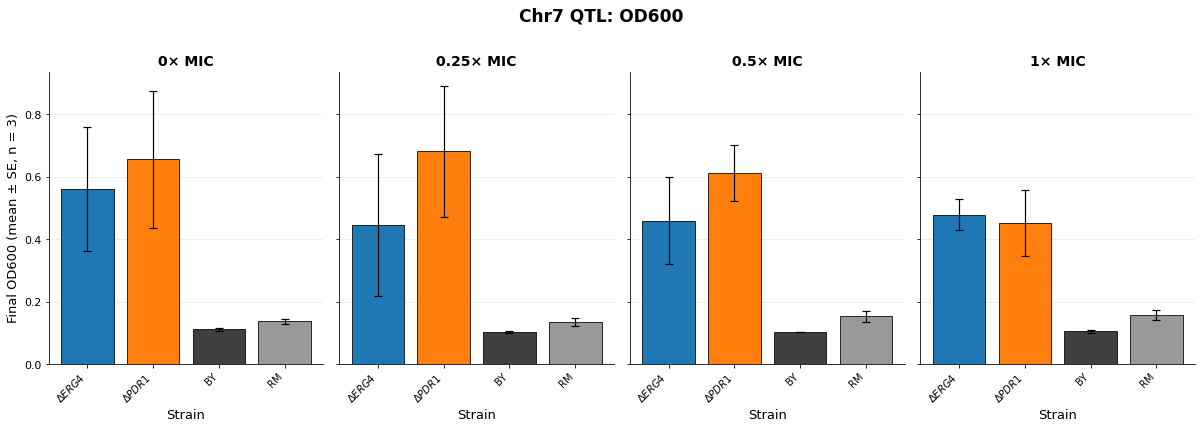

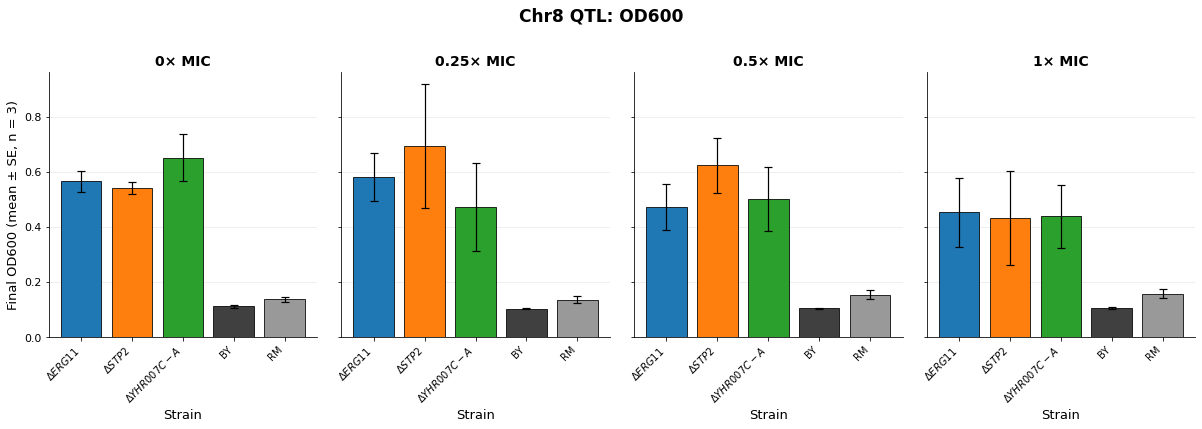

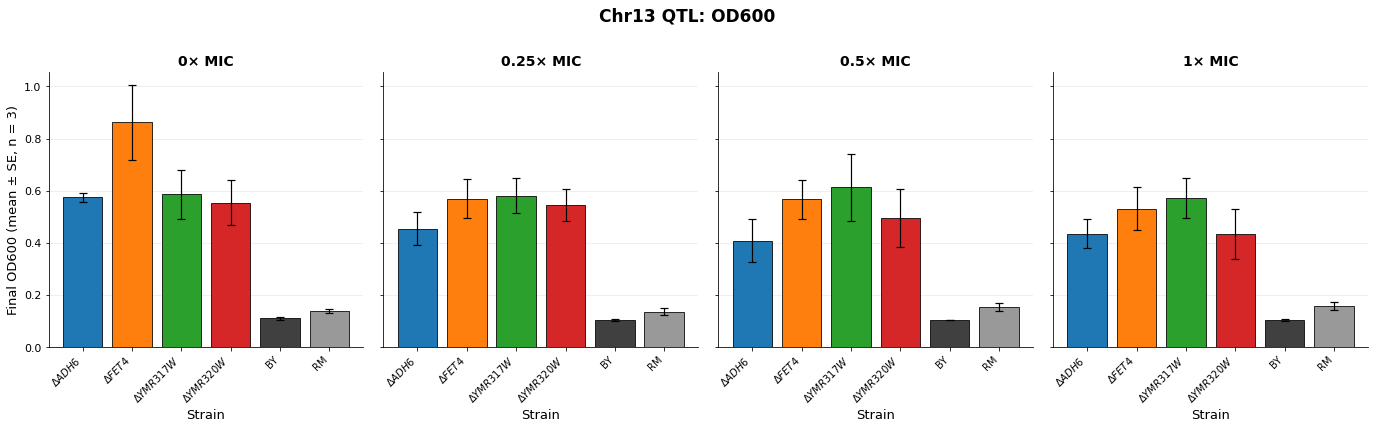

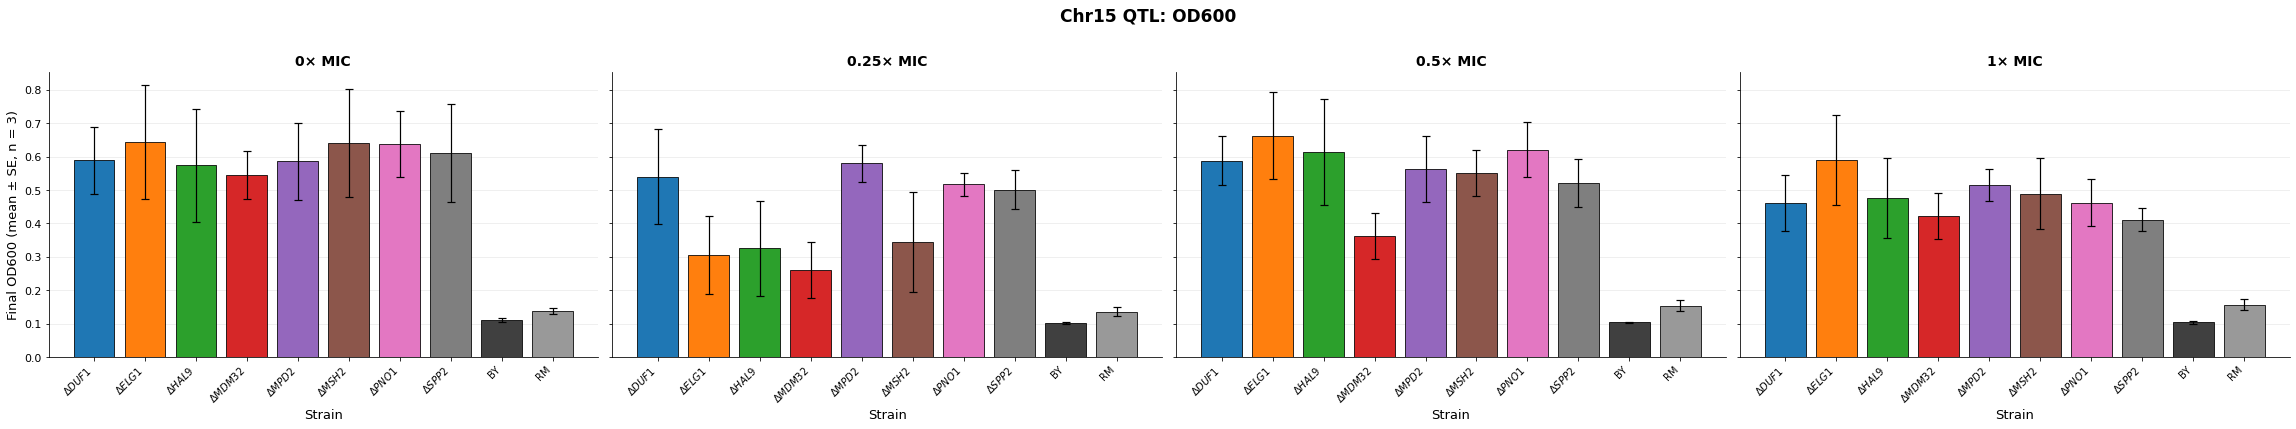


OD600 figures saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/OD600_1x4_figures


In [13]:
# ==========================================================
# Cell 8 — Generate four OD600 figures
# ==========================================================

od_figure_paths = []

for qtl_name, summary_df in OD_SUMMARIES.items():

    output_paths = plot_qtl_panels(
        summary_df=summary_df,
        qtl_name=qtl_name,
        metric_name="OD600",
        ylabel="Final OD600 (mean ± SE, n = 3)",
        output_dir=OD_OUTDIR,
        concentrations=CONCENTRATION_ORDER,
        add_zero_line=False,
        share_y=True,
        show_figure=True
    )

    od_figure_paths.extend(
        output_paths
    )

print(
    "\nOD600 figures saved to:",
    OD_OUTDIR
)

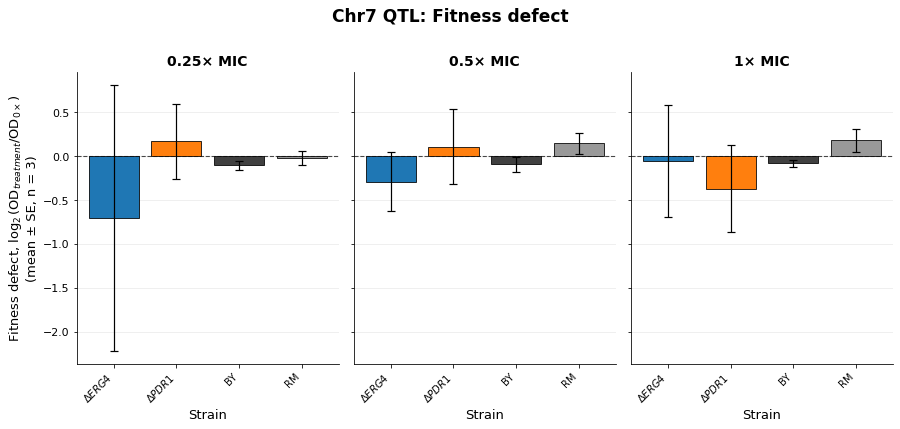

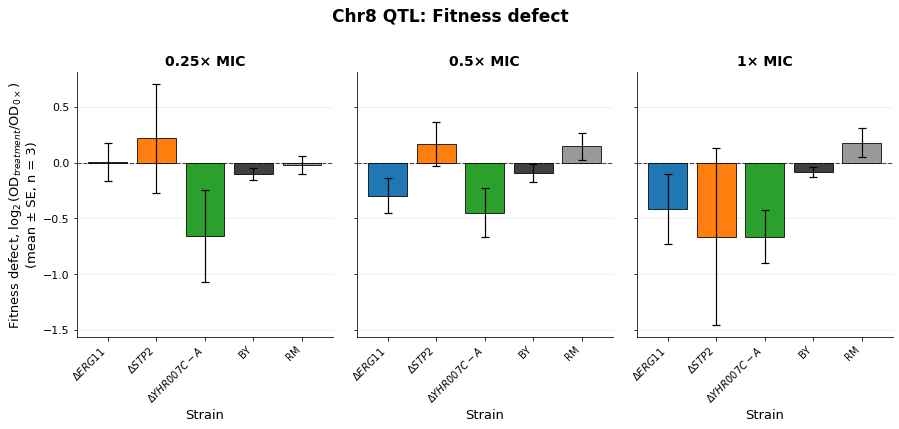

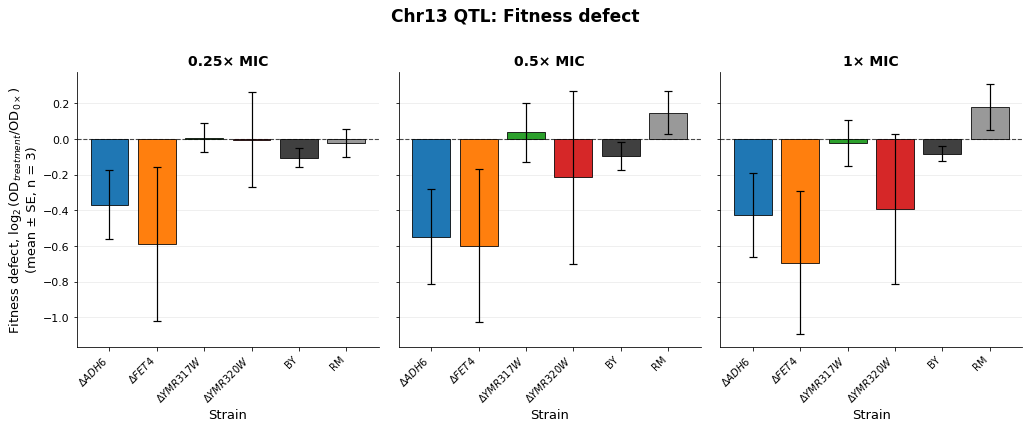

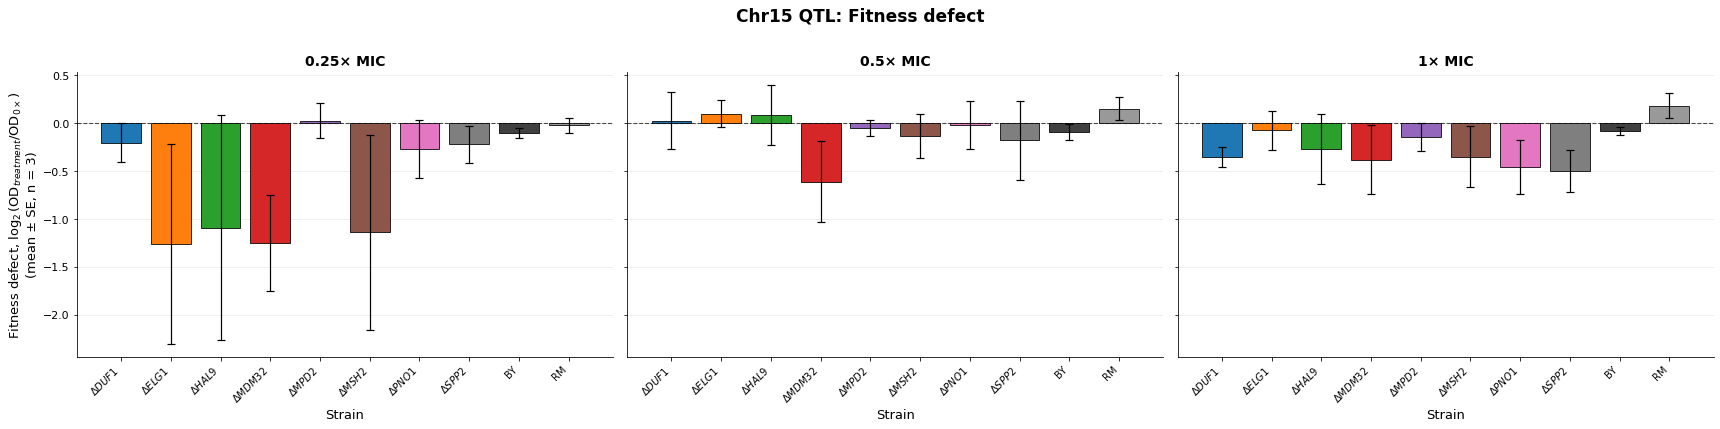


Fitness Defect figures saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/FD_1x4_figures


In [14]:
# ==========================================================
# Cell 9 — Generate four 1×3 Fitness Defect figures
# ==========================================================

FD_CONCENTRATION_ORDER = [
    "0.25x",
    "0.50x",
    "1.0x",
]

fd_figure_paths = []

for qtl_name, summary_df in FD_SUMMARIES.items():

    output_paths = plot_qtl_panels(
        summary_df=summary_df,
        qtl_name=qtl_name,
        metric_name="Fitness defect",
        ylabel=(
            r"Fitness defect, "
            r"$\log_2(\mathrm{OD}_{treatment}/"
            r"\mathrm{OD}_{0\times})$"
            "\n(mean ± SE, n = 3)"
        ),
        output_dir=FD_OUTDIR,
        concentrations=FD_CONCENTRATION_ORDER,
        add_zero_line=True,
        share_y=True,
        show_figure=True
    )

    fd_figure_paths.extend(
        output_paths
    )

print(
    "\nFitness Defect figures saved to:",
    FD_OUTDIR
)

In [11]:
# ==========================================================
# Cell 10 — Export all replicate-level values
# ==========================================================

all_replicate_data = pd.concat(
    [
        df.assign(
            QTL=qtl_name
        )
        for qtl_name, df
        in qtl_data_with_fd.items()
    ],
    ignore_index=True
)


all_replicate_data = all_replicate_data[
    [
        "QTL",
        "Concentration",
        "Strain",
        "Replicate",
        "OD600",
        "OD600_0x",
        "FD",
        "Source_file"
    ]
]


replicate_output_file = (
    SUMMARY_OUTDIR
    /
    "all_replicate_level_OD600_and_FD.csv"
)


all_replicate_data.to_csv(
    replicate_output_file,
    index=False
)


print(
    "Replicate-level data saved to:",
    replicate_output_file
)


all_replicate_data

Replicate-level data saved to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Dose-dependent/summary_tables/all_replicate_level_OD600_and_FD.csv


,QTL,Concentration,Strain,Replicate,OD600,OD600_0x,FD,Source_file
0,Chr7 QTL,0x,BY,1,0.261,0.261,0.000000,BY.xlsx
1,Chr7 QTL,0x,BY,2,0.532,0.532,0.000000,BY.xlsx
2,Chr7 QTL,0x,BY,3,1.122,1.122,0.000000,BY.xlsx
3,Chr7 QTL,0x,ERG4,1,0.444,0.444,0.000000,CHR7_QTL.xlsx
4,Chr7 QTL,0x,ERG4,2,0.406,0.406,0.000000,CHR7_QTL.xlsx
...,...,...,...,...,...,...,...,...
247,Chr15 QTL,1.0x,PNO1,2,0.544,0.678,-0.317679,CHR15_QTL.xlsx
248,Chr15 QTL,1.0x,PNO1,3,0.293,0.333,-0.184622,CHR15_QTL.xlsx
249,Chr15 QTL,1.0x,SPP2,1,0.372,0.287,0.374252,CHR15_QTL.xlsx
250,Chr15 QTL,1.0x,SPP2,2,0.358,0.396,-0.145541,CHR15_QTL.xlsx


In [12]:
# ==========================================================
# Cell 11 — Verify that BY occurs in every subplot
# ==========================================================

verification_rows = []

for qtl_name, df in qtl_data_with_fd.items():

    for concentration in CONCENTRATION_ORDER:

        panel = df.loc[
            df["Concentration"]
            == concentration
        ]

        strains = set(
            panel["Strain"]
        )

        by_rows = panel.loc[
            panel["Strain"] == "BY"
        ]

        verification_rows.append({
            "QTL": qtl_name,
            "Concentration": concentration,
            "BY_present": "BY" in strains,
            "BY_replicates": by_rows["Replicate"].nunique(),
            "Total_strains": panel["Strain"].nunique()
        })


verification_df = pd.DataFrame(
    verification_rows
)


if not verification_df["BY_present"].all():
    raise ValueError(
        "BY is missing from one or more panels."
    )


if not (
    verification_df["BY_replicates"] == 3
).all():
    raise ValueError(
        "BY does not have all three replicates "
        "in one or more panels."
    )


print(
    "Verification passed: BY is present with "
    "Rep1, Rep2, and Rep3 in every subplot."
)

verification_df

Verification passed: BY is present with Rep1, Rep2, and Rep3 in every subplot.


,QTL,Concentration,BY_present,BY_replicates,Total_strains
0,Chr7 QTL,0x,True,3,3
1,Chr7 QTL,0.25x,True,3,3
2,Chr7 QTL,0.50x,True,3,3
3,Chr7 QTL,1.0x,True,3,3
4,Chr8 QTL,0x,True,3,4
5,Chr8 QTL,0.25x,True,3,4
6,Chr8 QTL,0.50x,True,3,4
7,Chr8 QTL,1.0x,True,3,4
8,Chr13 QTL,0x,True,3,5
9,Chr13 QTL,0.25x,True,3,5
